In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 32 → 16
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 16 → 8
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 8 → 4
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 4 → 2
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model24_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model24_0)
describe(model24_0)

MACs: 6.31 MMac, Params: 32.13 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Starting


/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1/60: Train loss = 1.4655, Train accuracy = 0.4875, Test loss = 1.4583, Test accuracy = 0.4991
Epoch 2/60: Train loss = 0.9675, Train accuracy = 0.6575, Test loss = 0.9768, Test accuracy = 0.6609
Epoch 3/60: Train loss = 0.9832, Train accuracy = 0.6633, Test loss = 0.9644, Test accuracy = 0.6719
Epoch 4/60: Train loss = 0.8203, Train accuracy = 0.7102, Test loss = 0.8230, Test accuracy = 0.7109
Epoch 5/60: Train loss = 0.7566, Train accuracy = 0.7388, Test loss = 0.7688, Test accuracy = 0.7356
Epoch 6/60: Train loss = 0.7562, Train accuracy = 0.7349, Test loss = 0.7554, Test accuracy = 0.7390
Epoch 7/60: Train loss = 0.6727, Train accuracy = 0.7672, Test loss = 0.6630, Test accuracy = 0.7679
Epoch 8/60: Train loss = 0.6800, Train accuracy = 0.7679, Test loss = 0.6910, Test accuracy = 0.7616
Epoch 9/60: Train loss = 0.6658, Train accuracy = 0.7768, Test loss = 0.6889, Test accuracy = 0.7753
Epoch 10/60: Train loss = 0.5853, Train accuracy = 0.7979, Test loss = 0.5959, Test accurac

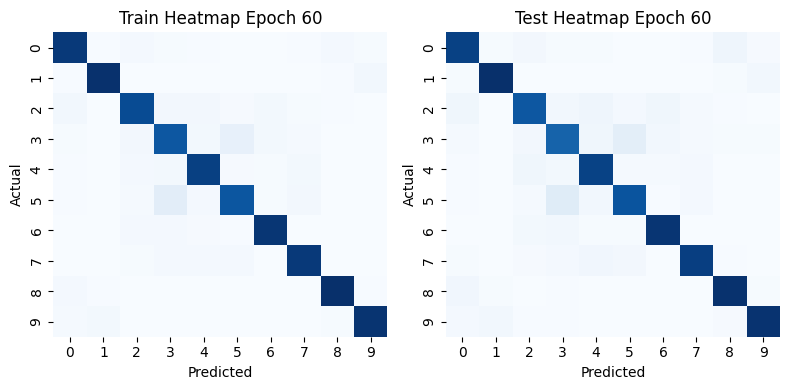

<Figure size 1200x600 with 0 Axes>

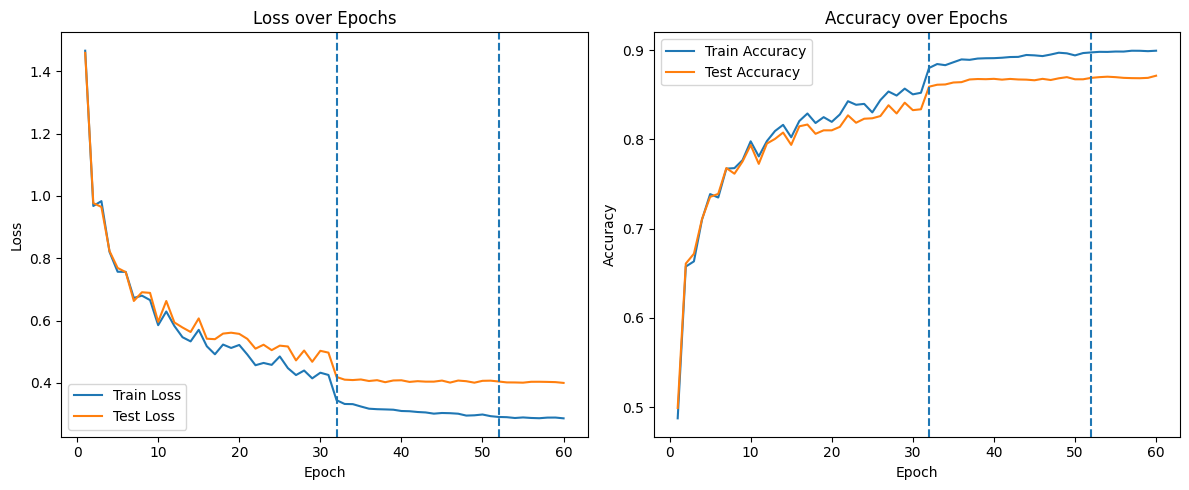

In [6]:
trainf32(model24_0,"model_weights/model24_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model24_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model24_1)
describe(model24_1)

MACs: 6.31 MMac, Params: 32.13 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Starting


/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1/60: Train loss = 1.1086, Train accuracy = 0.6113, Test loss = 1.0759, Test accuracy = 0.6262
Epoch 2/60: Train loss = 0.9363, Train accuracy = 0.6771, Test loss = 0.9335, Test accuracy = 0.6772
Epoch 3/60: Train loss = 0.7909, Train accuracy = 0.7253, Test loss = 0.7911, Test accuracy = 0.7286
Epoch 4/60: Train loss = 0.7183, Train accuracy = 0.7513, Test loss = 0.7265, Test accuracy = 0.7531
Epoch 5/60: Train loss = 0.7371, Train accuracy = 0.7505, Test loss = 0.7400, Test accuracy = 0.7534
Epoch 6/60: Train loss = 0.6807, Train accuracy = 0.7636, Test loss = 0.7018, Test accuracy = 0.7632
Epoch 7/60: Train loss = 0.6281, Train accuracy = 0.7819, Test loss = 0.6524, Test accuracy = 0.7745
Epoch 8/60: Train loss = 0.6582, Train accuracy = 0.7722, Test loss = 0.6671, Test accuracy = 0.7695
Epoch 9/60: Train loss = 0.6132, Train accuracy = 0.7845, Test loss = 0.6326, Test accuracy = 0.7852
Epoch 10/60: Train loss = 0.5891, Train accuracy = 0.7944, Test loss = 0.6159, Test accurac

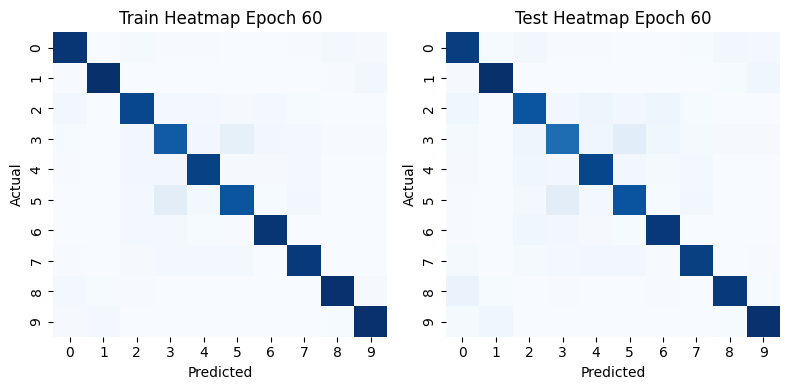

<Figure size 1200x600 with 0 Axes>

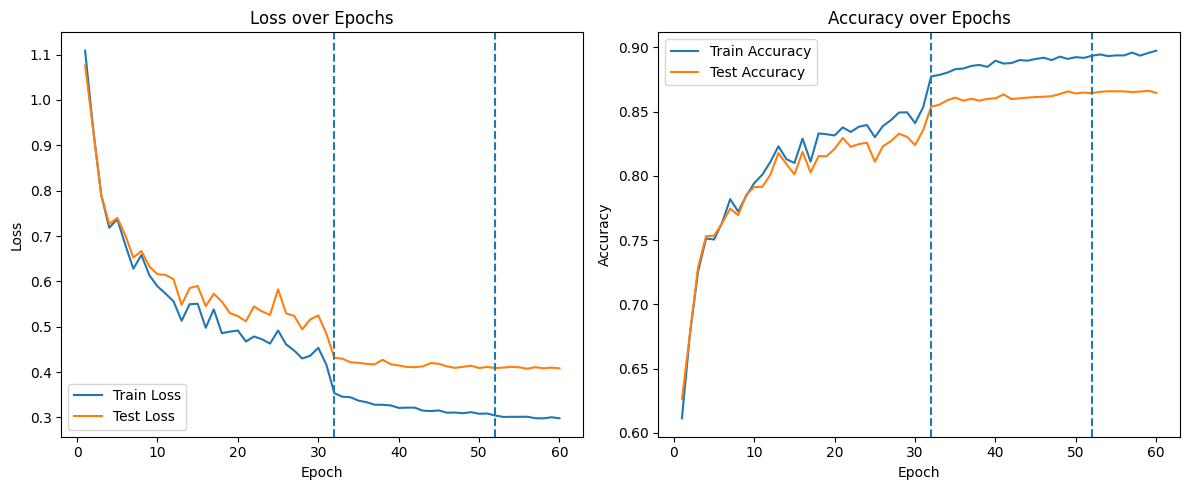

In [8]:
trainf32(model24_1,"model_weights/model24_1.pt",criterion,train_dataset,val_dataset, batch_size=64)